## BUSINESS PROBLEM:
A Retail store is required to analyze the day-to-day transactions and keep a track of its customers 
spread across various locations along with their purchases/returns across various categories. 
Create a report and display the below calculated metrics, reports and inferences.

## 1. Merge the datasets Customers, Product Hierarchy and Transactions as Customer_Final. Ensure to
#     keep all customers who have done transactions with us and select the join type accordingly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
customers = pd.read_csv('Customer.csv')
product = pd.read_csv('Prod_cat_info.csv')
transactions= pd.read_csv('Transactions.csv')

In [13]:
customers.columns

Index(['customer_Id', 'DOB', 'Gender', 'city_code'], dtype='object')

In [14]:
product.columns

Index(['prod_cat_code', 'prod_cat', 'prod_sub_cat_code', 'prod_subcat'], dtype='object')

In [15]:
transactions.columns

Index(['transaction_id', 'cust_id', 'tran_date', 'prod_subcat_code',
       'prod_cat_code', 'Qty', 'Rate', 'Tax', 'total_amt', 'Store_type'],
      dtype='object')

In [5]:
transactions_customers = pd.merge(transactions, customers, how='inner', left_on='cust_id', right_on='customer_Id')
customer_final=pd.merge(transactions_customers,product,how='inner',left_on='prod_cat_code',right_on='prod_cat_code')

In [6]:
customer_final

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,270351,26-09-1981,M,5.0,Clothing,4,Mens
1,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,270351,26-09-1981,M,5.0,Clothing,1,Women
2,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,270351,26-09-1981,M,5.0,Clothing,3,Kids
3,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,270384,11-05-1973,F,8.0,Electronics,4,Mobiles
4,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,270384,11-05-1973,F,8.0,Electronics,5,Computers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99288,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,271961,15-01-1982,M,1.0,Books,12,Academic
99289,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,271961,15-01-1982,M,1.0,Books,10,Non-Fiction
99290,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,271961,15-01-1982,M,1.0,Books,11,Children
99291,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,271961,15-01-1982,M,1.0,Books,3,Comics


## 2. Prepare a summary report for the merged data set.
#  a. Get the column names and their corresponding data types
#  b. Top/Bottom 10 observations
#  c. “Five-number summary” for continuous variables (min, Q1, median, Q3 and max)
#  d. Frequency tables for all the categorical variables

In [18]:
## a.  a. Get the column names and their corresponding data types
customer_final.dtypes

transaction_id         int64
cust_id                int64
tran_date             object
prod_subcat_code       int64
prod_cat_code          int64
Qty                    int64
Rate                   int64
Tax                  float64
total_amt            float64
Store_type            object
customer_Id            int64
DOB                   object
Gender                object
city_code            float64
prod_cat              object
prod_sub_cat_code      int64
prod_subcat           object
dtype: object

In [19]:
##  b. Top/Bottom 10 observations
customer_final.head(10)
customer_final.tail(10)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
99283,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,270911,22-05-1970,M,2.0,Books,10,Non-Fiction
99284,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,270911,22-05-1970,M,2.0,Books,11,Children
99285,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,270911,22-05-1970,M,2.0,Books,3,Comics
99286,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,270911,22-05-1970,M,2.0,Books,6,DIY
99287,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,271961,15-01-1982,M,1.0,Books,7,Fiction
99288,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,271961,15-01-1982,M,1.0,Books,12,Academic
99289,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,271961,15-01-1982,M,1.0,Books,10,Non-Fiction
99290,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,271961,15-01-1982,M,1.0,Books,11,Children
99291,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,271961,15-01-1982,M,1.0,Books,3,Comics
99292,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,271961,15-01-1982,M,1.0,Books,6,DIY


In [20]:
## c. “Five-number summary” for continuous variables (min, Q1, median, Q3 and max)
summary=customer_final.describe()

five_number_summary = summary.loc[['min', '25%', '50%', '75%', 'max']]
five_number_summary

,transaction_id,cust_id,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,customer_Id,city_code,prod_sub_cat_code
min,3.268991e+06,266783.0,1.0,1.0,-5.0,-1499.0,7.350,-8270.925,266783.0,1.0,1.0
25%,2.492150e+10,268956.0,4.0,3.0,1.0,313.0,98.280,762.450,268956.0,3.0,4.0
50%,5.011083e+10,270982.0,7.0,5.0,3.0,713.0,199.920,1761.370,270982.0,5.0,7.0
75%,7.528121e+10,273120.0,10.0,5.0,4.0,1109.0,366.975,3585.725,273120.0,8.0,10.0
max,9.998755e+10,275265.0,12.0,6.0,5.0,1500.0,787.500,8287.500,275265.0,10.0,12.0


In [21]:
## d. Frequency tables for all the categorical variables
for column in customer_final.columns:
    if customer_final[column].dtype == 'object':
        print(f"Frequency table for {column}:")
        print(customer_final[column].value_counts())
        print("\n")  

Frequency table for tran_date:
tran_date
25-08-2012    153
13-07-2011    144
25-09-2011    144
3/2/2014      142
21-12-2013    141
             ... 
22-02-2014     11
24-02-2014     10
21-02-2014      5
27-02-2014      5
28-02-2014      3
Name: count, Length: 1129, dtype: int64


Frequency table for Store_type:
Store_type
e-Shop            40185
MBR               19974
Flagship store    19814
TeleShop          19320
Name: count, dtype: int64


Frequency table for DOB:
DOB
27-12-1988    156
17-09-1982    134
25-02-1974    126
18-11-1991    114
09-06-1970    107
             ... 
14-12-1988      2
09-05-1976      2
11-10-1991      2
05-08-1980      2
02-08-1991      2
Name: count, Length: 3987, dtype: int64


Frequency table for Gender:
Gender
M    51051
F    48202
Name: count, dtype: int64


Frequency table for prod_cat:
prod_cat
Books               36414
Electronics         24490
Home and kitchen    16516
Footwear             8997
Clothing             8880
Bags                 3996
Nam

## 3. Generate histograms for all continuous variables and frequency bars for categorical variables.


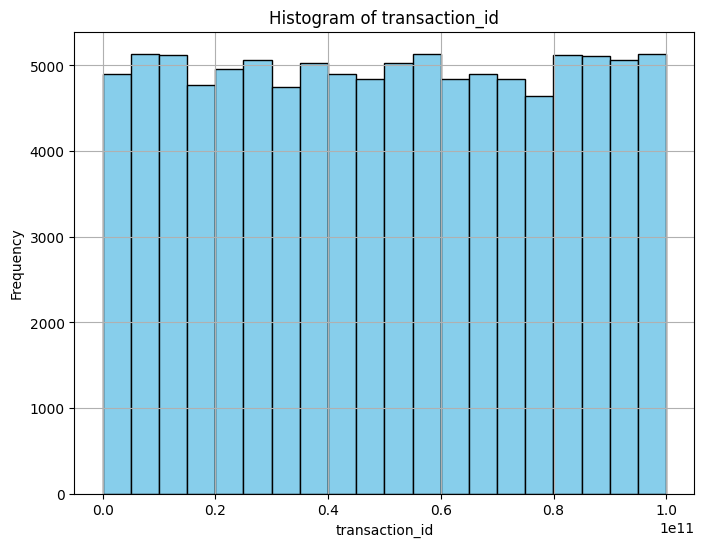

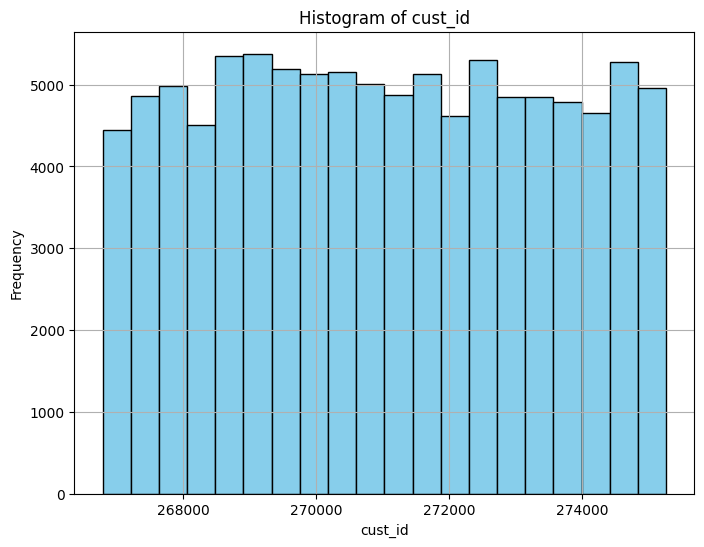

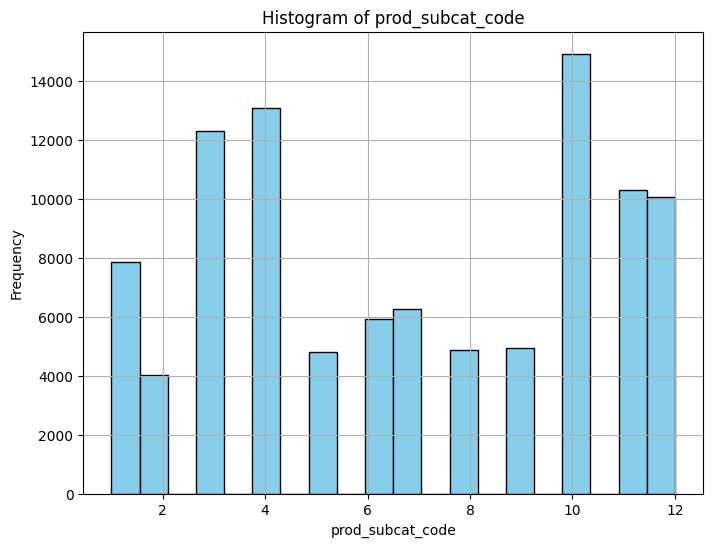

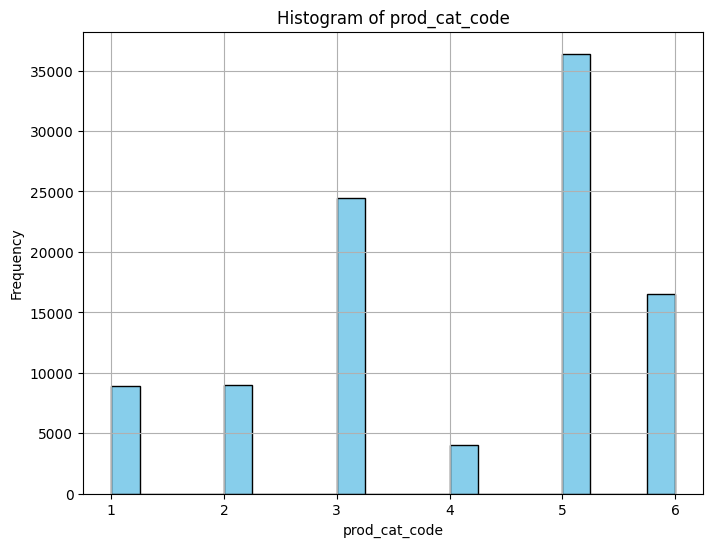

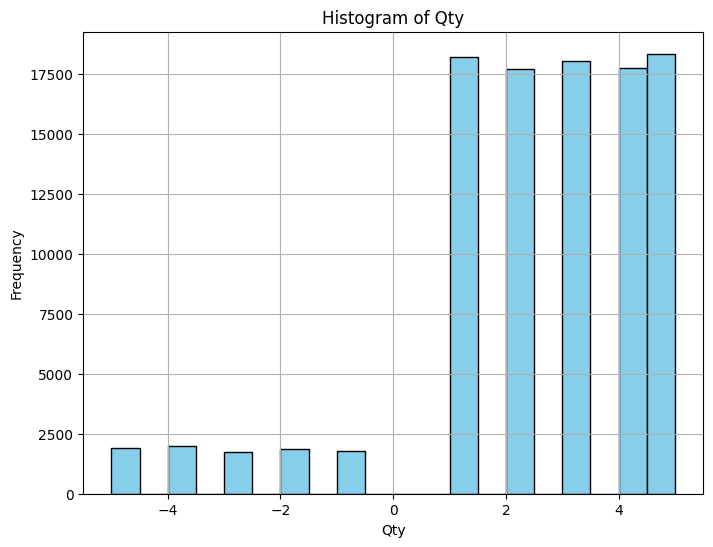

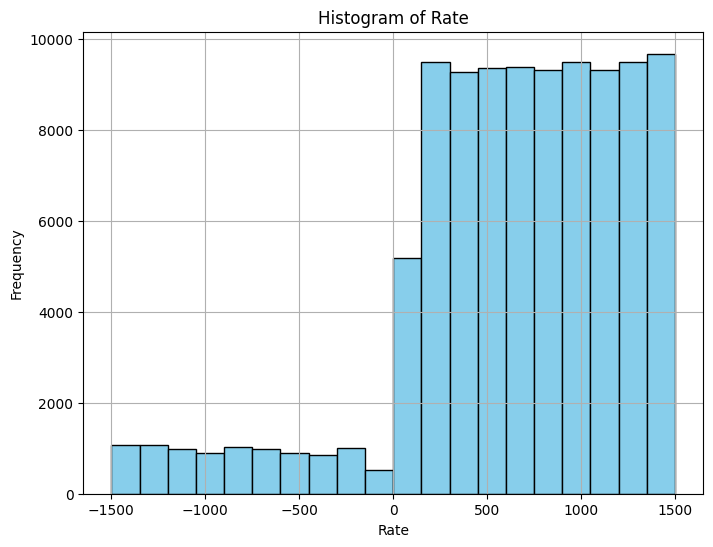

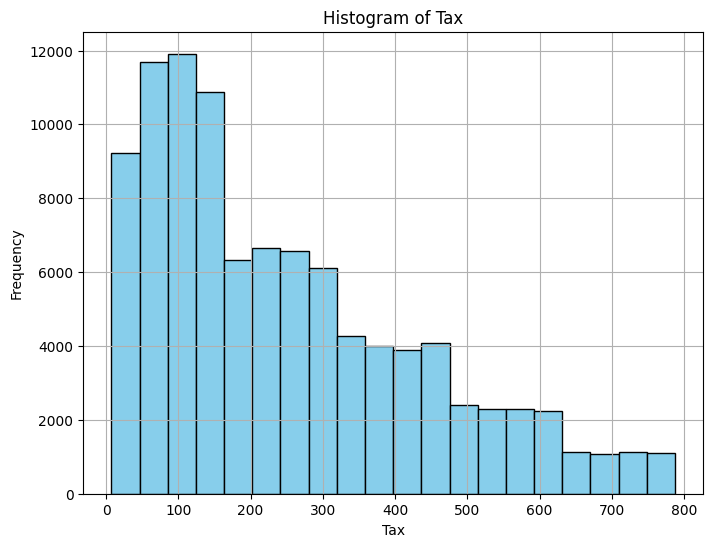

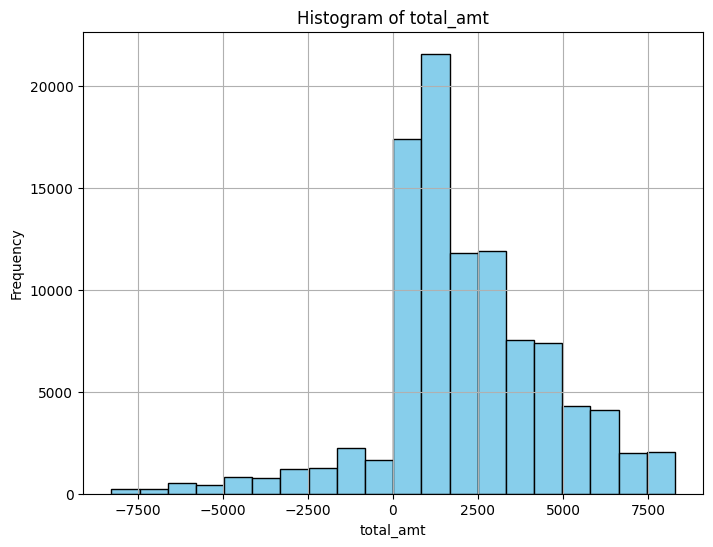

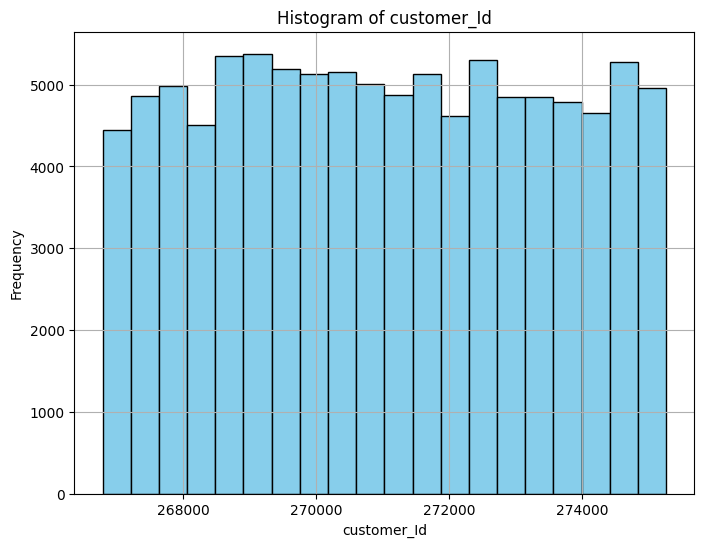

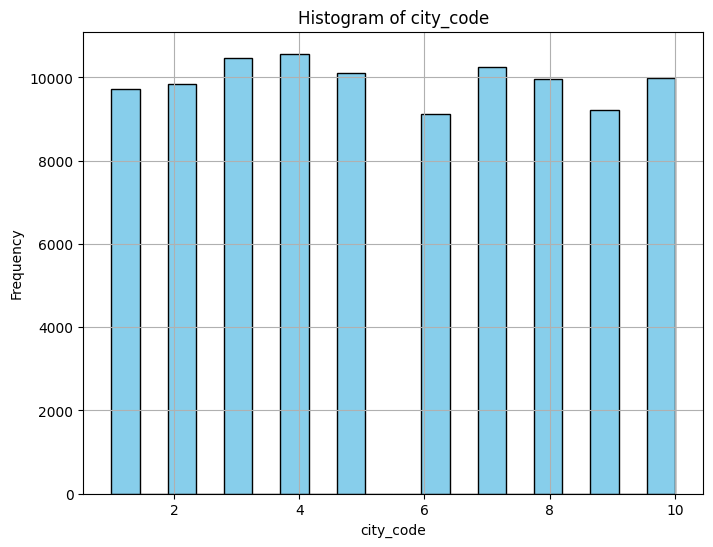

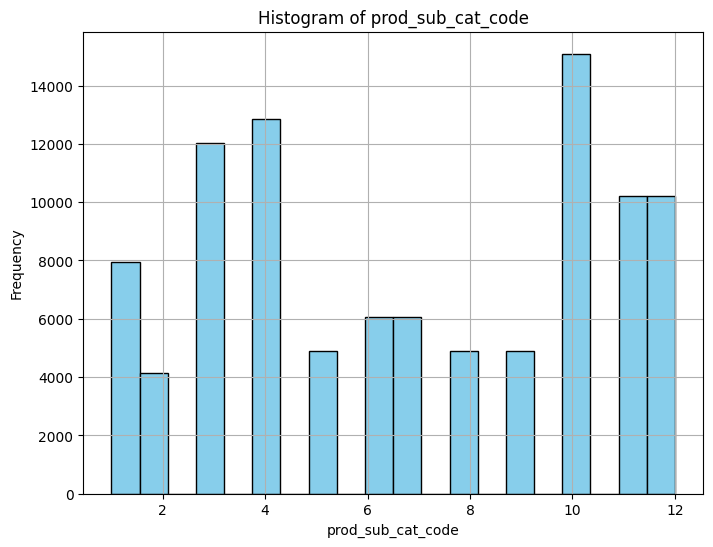

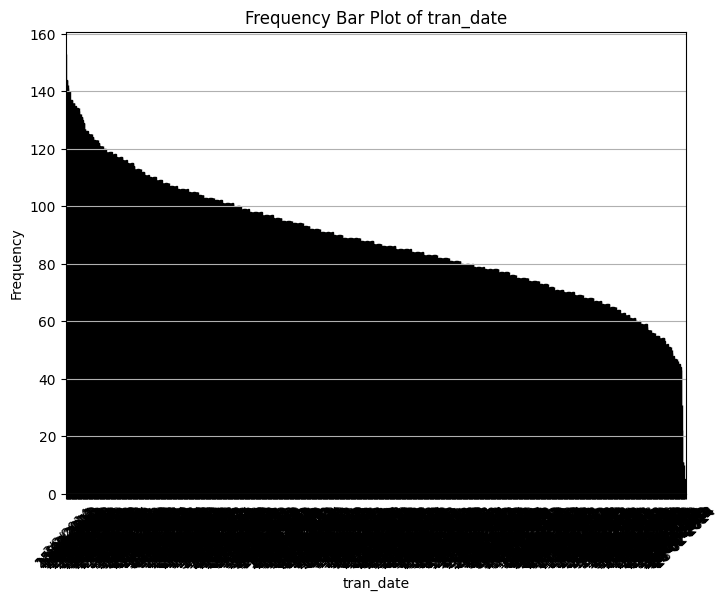

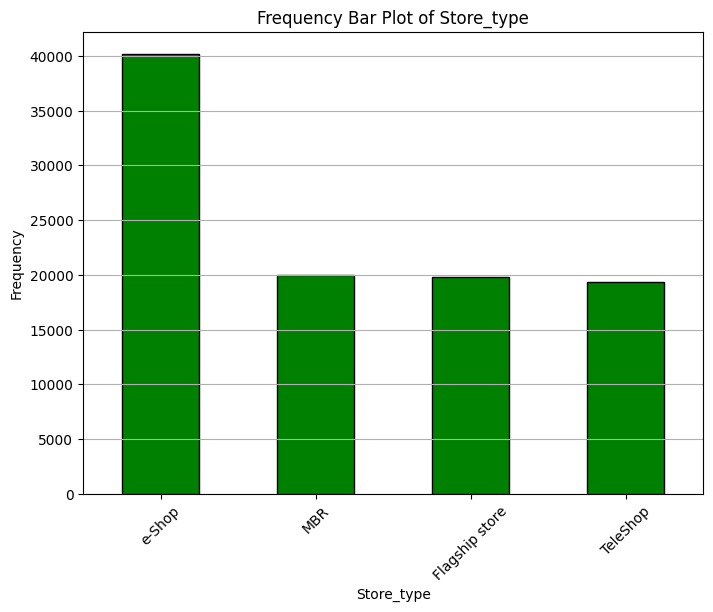

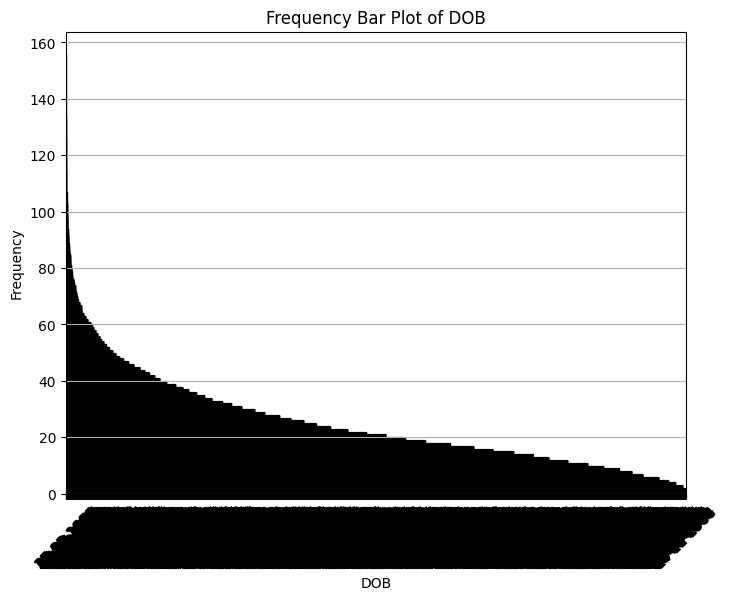

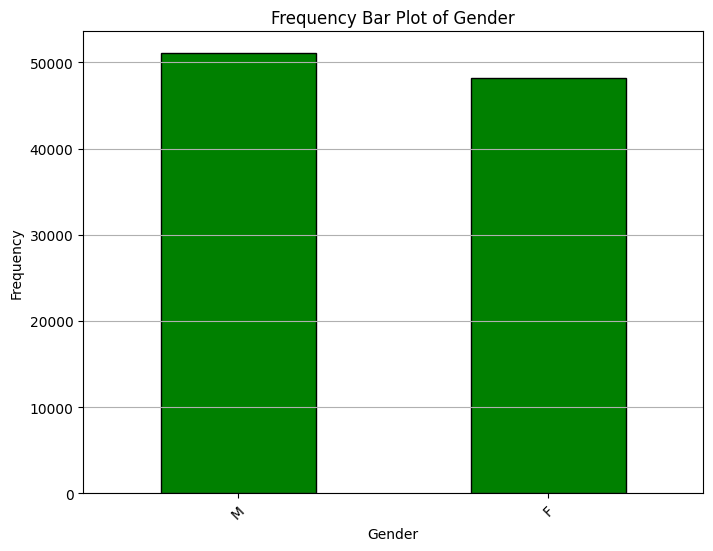

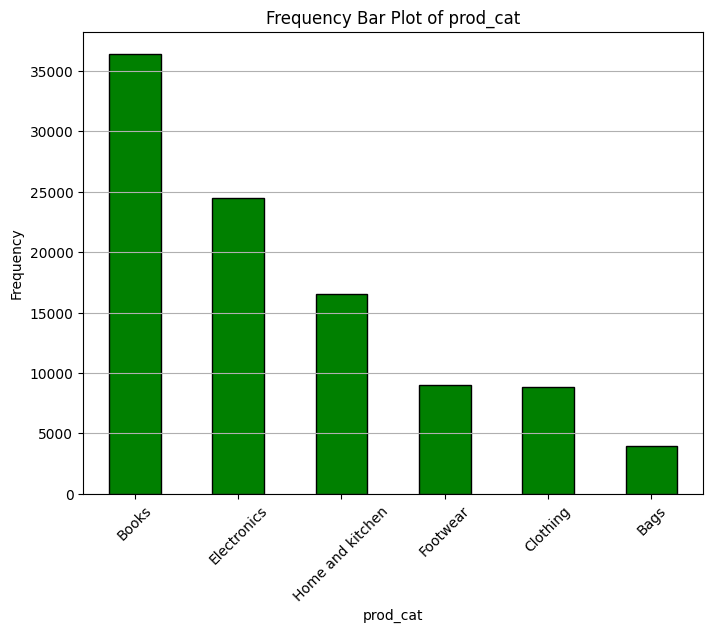

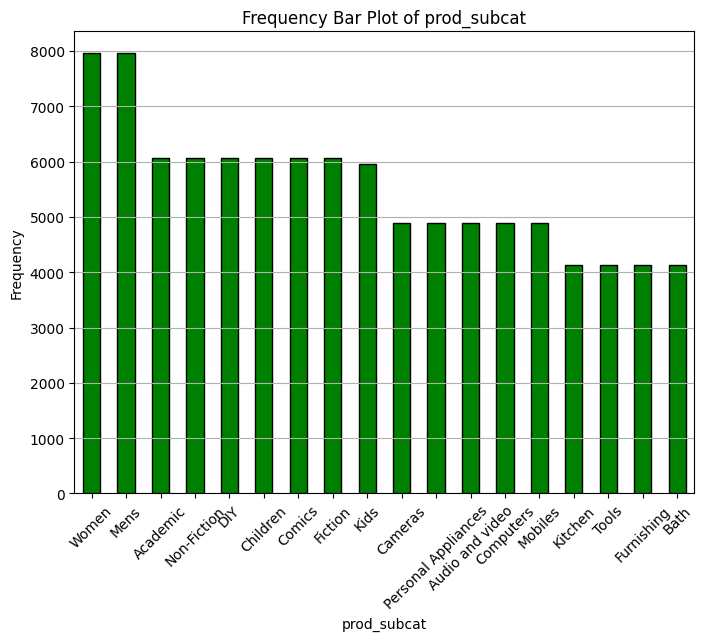

In [51]:
continuous_variables = customer_final.select_dtypes(include=['float64', 'int64'])

for column in continuous_variables.columns:
    plt.figure(figsize=(8, 6))
    plt.hist(customer_final[column], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

categorical_variables = customer_final.select_dtypes(include=['object'])

for column in categorical_variables.columns:
    plt.figure(figsize=(8, 6))
    customer_final[column].value_counts().plot(kind='bar', color='g', edgecolor='black')
    plt.title(f'Frequency Bar Plot of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(axis='y')
    plt.xticks(rotation=45)
    plt.show()

# 4. Calculate the following information using the merged dataset :
# a. Time period of the available transaction data
# b. Count of transactions where the total amount of transaction was negative.

In [7]:
# a. Time period of the available transaction data
customer_final.sort_values(by='tran_date',inplace=True)
earliest_date=customer_final['tran_date'].min()
latest_date=customer_final['tran_date'].max()

In [9]:
# b. Count of transactions where the total amount of transaction was negative.
tot_nega_transaction = len(customer_final[customer_final['total_amt']<0])
tot_nega_transaction

9294

## 5. Analyze which product categories are more popular among females vs male customers.

In [26]:
customer_final.pivot_table(index='prod_cat',columns='Gender',values='Qty',aggfunc='sum').idmax()

Gender
F    Books
M    Books
dtype: object

## 6. Which City code has the maximum customers and what was the percentage of customers from that city?

In [13]:
tot_cust = customer_final.groupby('city_code').size().reset_index(name='tot_cust').sort_values(by = 'tot_cust',ascending=False)
tot_cust['cust_percentage'] = ((tot_cust['tot_cust']/tot_cust['tot_cust'].sum())*100).round(2)
tot_cust.head(1)

,city_code,tot_cust,cust_percentage
3,4.0,10571,10.65


## 7. Which store type sells the maximum products by value and by quantity?

In [27]:
customer_final.groupby(['Store_type']).agg({'Qty':'sum','total_amt':'sum'}).sort_values(by=['Qty','total_amt'],ascending=False).head(1)


,Qty,total_amt
Store_type,,
e-Shop,98447,85915747.84


## 8. What was the total amount earned from the "Electronics" and "Clothing" categories from Flagship Stores?

In [56]:
flagship_transactions = customer_final[customer_final['Store_type'] == 'Flagship store']

electronic_clothing_transactions = flagship_transactions[flagship_transactions['prod_cat'].isin(['Electronics', 'Clothing'])]

total_amount_earned = electronic_clothing_transactions['total_amt'].sum()

print(f"Total amount earned from Electronics and Clothing categories at Flagship Stores: {total_amount_earned}")

Total amount earned from Electronics and Clothing categories at Flagship Stores: 14658949.89


## 9. What was the total amount earned from "Male" customers under the "Electronics" category?

In [57]:
male_transactions = customer_final[customer_final['Gender'] == 'Male']
male_electronics_transactions = male_transactions[male_transactions['prod_cat'] == 'Electronics']

total_amount_earned_male_electronics = male_electronics_transactions['total_amt'].sum()

print(f"Total amount earned from 'Male' customers under the 'Electronics' category: {total_amount_earned_male_electronics}")

Total amount earned from 'Male' customers under the 'Electronics' category: 0.0


## 10. How many customers have more than 10 unique transactions, after removing all transactions which have any negative amounts?

In [47]:
non_neg_tran = customer_final[customer_final['total_amt']> 0].groupby('cust_id').size().reset_index(name = 'tot_tran')
non_neg_tran[non_neg_tran['tot_tran']>=10].shape[0]

4254

## 11. For all customers aged between 25 - 35, find out:
# a. What was the total amount spent for “Electronics” and “Books” product categories?
# b. What was the total amount spent by these customers between 1st Jan, 2014 to 1st Mar, 2014?

In [54]:
customer_final['tran_date'] = pd.to_datetime(
    customer_final['tran_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)


In [56]:
customer_final['DOB']= pd.to_datetime(customer_final['DOB'],dayfirst=True)

In [65]:
## A.
## i. Extract age using columns tran_date and DOB
customer_final['Age'] = (customer_final['tran_date'] - customer_final['DOB']).dt.days // 365

In [66]:
 ## ii.the total amount spent for “Electronics” and “Books” product categories
(customer_final[(customer_final['Age']>=25) & (customer_final['Age']<=35)
    & (customer_final['prod_cat'].isin(['Electronics','Books']))].groupby('prod_cat')['total_amt'].sum().reset_index())

,prod_cat,total_amt
0,Books,36672578.67
1,Electronics,25401065.95


In [67]:
## B.What was the total amount spent by these customers between 1st Jan, 2014 to 1st Mar, 2014
total_amount_spent = customer_final[
    (customer_final['Age'] >= 25) & (customer_final['Age'] <= 35) &
    (customer_final['tran_date'] >= '2014-01-01') &
    (customer_final['tran_date'] <= '2014-03-01')
]['total_amt'].sum()

total_amount_spent

np.float64(4505565.675000001)